## 2. Exponential Regression

### Theory

Exponential regression fits data that grows or decays exponentially.

**Model Equation:**

$$y = a \cdot e^{bx}$$

Where:
- $a$ = initial value (when $x = 0$)
- $b$ = growth rate ($b > 0$ = growth, $b < 0$ = decay)

**Linearization:**

Take natural logarithm of both sides:

$$\ln(y) = \ln(a) + bx$$

Let:
- $Y = \ln(y)$
- $A = \ln(a)$
- $B = b$
- $X = x$

Then the equation becomes linear:

$$Y = A + BX$$

**Transformed Normal Equations:**

$$B = \frac{n\sum x \ln y - \sum x \sum \ln y}{n\sum x^2 - (\sum x)^2}$$

$$A = \frac{\sum \ln y - B\sum x}{n}$$

**Convert Back:**

$$a = e^{A}$$

$$b = B$$

**Algorithm:**

1. Transform data: $\ln y_i = \ln(y_i)$ for $i = 1$ to $n$
2. Apply linear regression to $(x_i, \ln y_i)$:
   - $B = \frac{n\sum x \ln y - \sum x \sum \ln y}{n\sum x^2 - (\sum x)^2}$
   - $A = \frac{\sum \ln y - B\sum x}{n}$
3. Convert back: $a = e^{A}$, $b = B$
4. Return $y = a \cdot e^{bx}$


Fitted exponential curve: y = 1.00 * e^(1.00 x)
Or: y = 0.9955 * exp(1.0012x)
R² = 1.0000


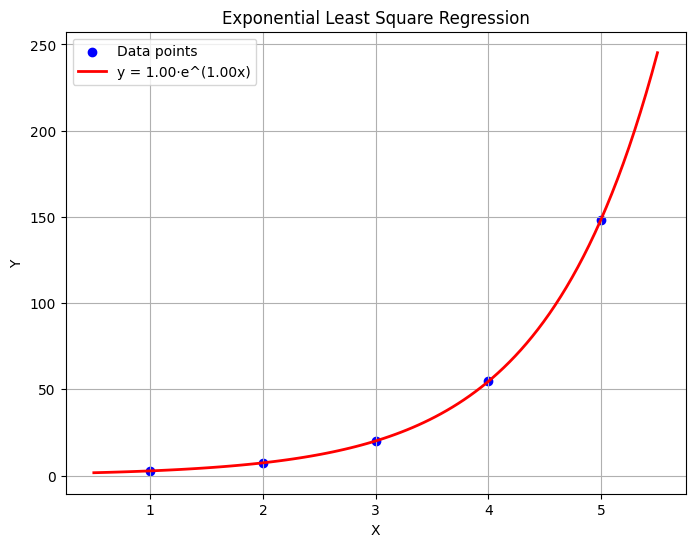

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Exponential Least Square
# Model: y = a * e^(b*x)
# Take ln both sides: ln(y) = ln(a) + b*x

x = np.array([1, 2, 3, 4, 5], dtype=np.float32)
y = np.array([2.7, 7.4, 20.1, 54.6, 148.4], dtype=np.float32)  # Exponential data

n = len(x)

# Transform y to ln(y)
Y = np.log(y)

# Calculate sums for linear regression on transformed data
sumx = 0
sumx2 = 0
sumY = 0
sumx_Y = 0

# print("=" * 40)
# print("EXPONENTIAL LEAST SQUARE")
# print("=" * 40)
# print("\nOriginal data:")
# for i in range(n):
#     print(f"  x={x[i]}, y={y[i]}, ln(y)={ln_y[i]:.4f}")

for i in range(n):
    sumx += x[i]
    sumY += Y[i]
    sumx2 += x[i]**2
    sumx_Y += x[i] * Y[i]

# Calculate coefficients for ln(y) = ln(a) + b*x
denominator = n * sumx2 - sumx * sumx
b = (n * sumx_Y - sumx * sumY) / denominator
A = (sumY - b * sumx) / n
a = np.exp(A)

print(f"\nFitted exponential curve: y = {a:.2f} * e^({b:.2f} x)")
print(f"Or: y = {a:.4f} * exp({b:.4f}x)")

# Calculate predicted values
y_pred = a * np.exp(b * x)

# Calculate R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"R² = {r2:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Data points')

x_curve = np.linspace(min(x)-0.5, max(x)+0.5, 100)
y_curve = a * np.exp(b * x_curve)
plt.plot(x_curve, y_curve, color='red', linewidth=2, label=f'y = {a:.2f}·e^({b:.2f}x)')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Exponential Least Square Regression')
plt.legend()
plt.grid(True)
plt.show()